## Step 1: Environment Setup and Image Loading
### Aim:
To extract meaningful features from an image using basic feature extraction techniques and represent the image in numerical form for Machine Learning applications[cite: 5].

### Workflow:
Input Image → Preprocessing → Grayscale Image → Segmentation / Thresholding → Feature Extraction (Intensity, Shape, Texture) → Feature Vector → Ready for ML Algorithm[cite: 5].

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from google.colab import files

# Upload an image (or download a default defect/object sample if none provided)
print("Upload an object/defect image (or cancel to use default sample):")
try:
    uploaded = files.upload()
    filename = next(iter(uploaded))
    img_bgr = cv2.imread(filename)
except Exception:
    import urllib.request
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/board.jpg"
    urllib.request.urlretrieve(url, "sample_object.jpg")
    img_bgr = cv2.imread("sample_object.jpg")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"Image successfully loaded with shape: {img_rgb.shape}")

Upload an object/defect image (or cancel to use default sample):


Saving machinery-cracking-600x300px.jpg to machinery-cracking-600x300px.jpg
Image successfully loaded with shape: (300, 600, 3)


## Step 2: Image Preprocessing and Grayscale Conversion
We convert the input image to grayscale to simplify pixel intensity values into a single channel (0–255)[cite: 5]. We apply Gaussian filtering to suppress camera sensor noise without destroying structural boundaries[cite: 5].

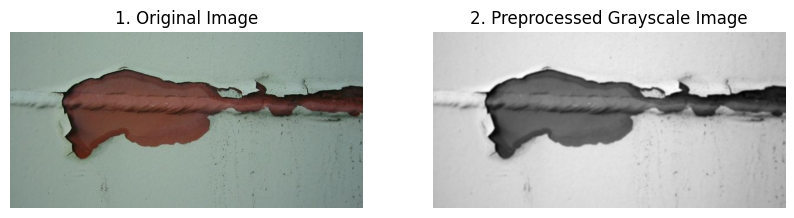

In [2]:
# Convert to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Apply Gaussian filter to smooth noise
img_filtered = cv2.GaussianBlur(img_gray, (5, 5), 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("1. Original Image")
axes[0].axis("off")

axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title("2. Preprocessed Grayscale Image")
axes[1].axis("off")
plt.show()

## Step 3: Segmentation and Contour Detection
We use **Otsu's thresholding** to binarize the object/defect region from the background automatically[cite: 5]. Then, we find the largest external contour representing the primary region of interest (ROI)[cite: 5].

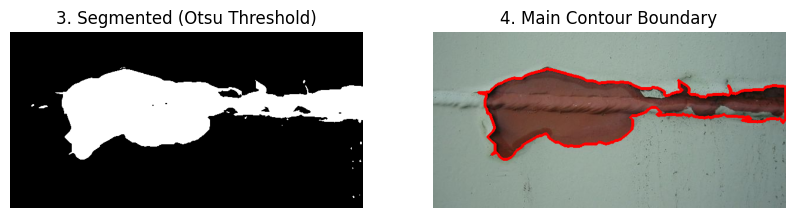

In [3]:
# Automatic Otsu's thresholding
_, thresh = cv2.threshold(img_filtered, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Extract contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Select the largest contour
main_contour = max(contours, key=cv2.contourArea)

# Create contour visual overlay
img_contour = img_rgb.copy()
cv2.drawContours(img_contour, [main_contour], -1, (255, 0, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(thresh, cmap='gray')
axes[0].set_title("3. Segmented (Otsu Threshold)")
axes[0].axis("off")

axes[1].imshow(img_contour)
axes[1].set_title("4. Main Contour Boundary")
axes[1].axis("off")
plt.show()

## Step 4: Feature Extraction
We extract numerical features spanning three fundamental categories[cite: 5]:
1. **Intensity Features:** Mean intensity and Standard deviation of the segmented region[cite: 5].
2. **Shape Features:** Area, Perimeter, Aspect Ratio, and Circularity ($4\pi \times \text{Area} / \text{Perimeter}^2$)[cite: 5].
3. **Texture Features:** Gray-Level Co-occurrence Matrix (GLCM) contrast, energy, and homogeneity[cite: 5].

In [4]:
# 1. Intensity Features (within segmented mask)
mask = np.zeros(img_gray.shape, dtype=np.uint8)
cv2.drawContours(mask, [main_contour], -1, 255, -1)
roi_pixels = img_gray[mask == 255]

mean_intensity = float(np.mean(roi_pixels)) if len(roi_pixels) > 0 else float(np.mean(img_gray))
std_intensity = float(np.std(roi_pixels)) if len(roi_pixels) > 0 else float(np.std(img_gray))

# 2. Shape Features
area = float(cv2.contourArea(main_contour))
perimeter = float(cv2.arcLength(main_contour, True))
x, y, w, h = cv2.boundingRect(main_contour)
aspect_ratio = float(w) / h if h != 0 else 0.0
circularity = float((4 * np.pi * area) / (perimeter ** 2)) if perimeter > 0 else 0.0

# 3. Texture Features via GLCM
glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contrast = float(graycoprops(glcm, 'contrast')[0, 0])
homogeneity = float(graycoprops(glcm, 'homogeneity')[0, 0])
energy = float(graycoprops(glcm, 'energy')[0, 0])

# Structure into the required table format
features_data = [
    {"Feature Category": "Intensity", "Feature": "Mean intensity", "Value": round(mean_intensity, 2)},
    {"Feature Category": "Intensity", "Feature": "Standard deviation", "Value": round(std_intensity, 2)},
    {"Feature Category": "Shape", "Feature": "Area", "Value": round(area, 2)},
    {"Feature Category": "Shape", "Feature": "Perimeter", "Value": round(perimeter, 2)},
    {"Feature Category": "Shape", "Feature": "Aspect Ratio", "Value": round(aspect_ratio, 2)},
    {"Feature Category": "Shape", "Feature": "Circularity", "Value": round(circularity, 2)},
    {"Feature Category": "Texture", "Feature": "GLCM Contrast", "Value": round(contrast, 2)},
    {"Feature Category": "Texture", "Feature": "GLCM Homogeneity", "Value": round(homogeneity, 2)},
]

df_features = pd.DataFrame(features_data)
display(df_features)

,Feature Category,Feature,Value
0,Intensity,Mean intensity,70.17
1,Intensity,Standard deviation,23.25
2,Shape,Area,38418.00
3,Shape,Perimeter,1517.69
4,Shape,Aspect Ratio,3.40
5,Shape,Circularity,0.21
6,Texture,GLCM Contrast,36.83
7,Texture,GLCM Homogeneity,0.49


## Step 5: Final Feature Vector Representation
We flatten the extracted numerical parameters into a single vector $X$, converting the raw visual matrix into a standardized numerical input ready for classification algorithms (Random Forest, SVM, or k-NN)[cite: 5].

In [5]:
# Construct 1D Feature Vector
feature_vector = [
    round(mean_intensity, 2),
    round(std_intensity, 2),
    round(area, 2),
    round(perimeter, 2),
    round(aspect_ratio, 2),
    round(circularity, 2),
    round(contrast, 2),
    round(homogeneity, 2)
]

print("="*60)
print("FEATURE VECTOR READY FOR ML CLASSIFIER:")
print(f"X = {feature_vector}")
print("="*60)
print(f"Total features extracted: {len(feature_vector)}")

FEATURE VECTOR READY FOR ML CLASSIFIER:
X = [70.17, 23.25, 38418.0, 1517.69, 3.4, 0.21, 36.83, 0.49]
Total features extracted: 8


## Step 6: Full Visualization Summary
Displaying the complete progression from raw input to contour extraction and feature vector generation[cite: 5].

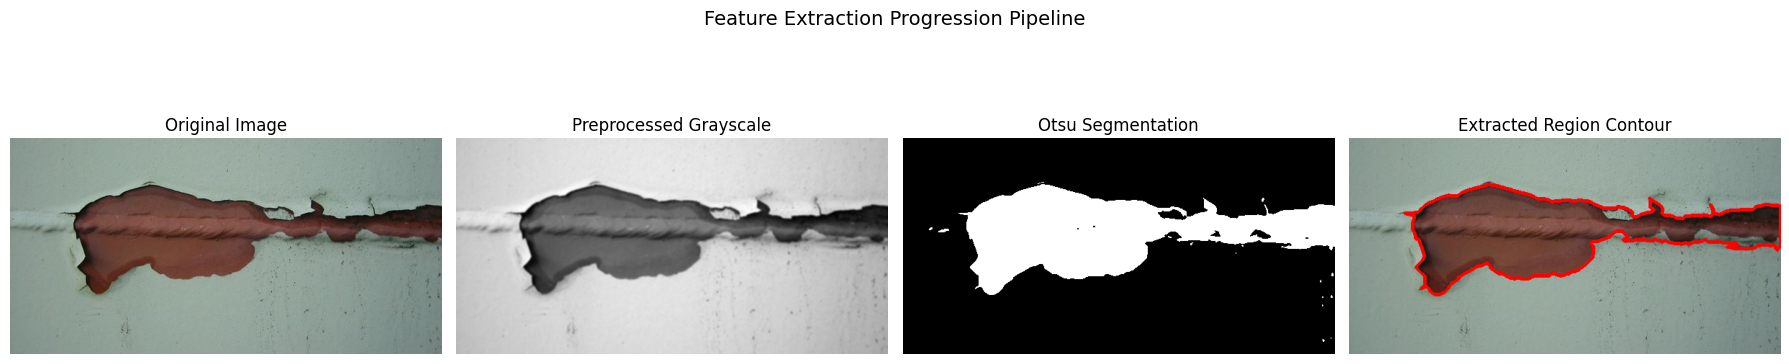

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_rgb); axes[0].set_title("Original Image"); axes[0].axis("off")
axes[1].imshow(img_filtered, cmap='gray'); axes[1].set_title("Preprocessed Grayscale"); axes[1].axis("off")
axes[2].imshow(thresh, cmap='gray'); axes[2].set_title("Otsu Segmentation"); axes[2].axis("off")
axes[3].imshow(img_contour); axes[3].set_title("Extracted Region Contour"); axes[3].axis("off")

plt.suptitle("Feature Extraction Progression Pipeline", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## Conclusion
In this practical, meaningful numerical representations were successfully extracted from an object/defect image using OpenCV and Scikit-Image[cite: 5]:
1. **Intensity features** (mean and standard deviation) quantified the surface reflectivity and illumination variance[cite: 5].
2. **Shape features** (area, perimeter, aspect ratio, and circularity) quantified geometric proportions and contour boundary complexity[cite: 5].
3. **Texture features** (GLCM contrast and homogeneity) captured surface roughness and recurring local patterns[cite: 5].
4. Combining these metrics into a unified feature vector $X$ converts unstructured pixel data into structured tabular data, making it directly consumable by machine learning classifiers like **Support Vector Machines (SVM)** or **Random Forest** for automated defect/object classification[cite: 5].